In [18]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os

Versions for libraries imported 

In [19]:
print(np.__version__)
print(matplotlib.__version__)
print(pd.__version__)


1.26.4
3.10.6
2.3.3


In [73]:


Experiment1Folder="VehicleExperiment_Output"
Experiment2Folder="SpeedExperiment_Cars_Output"
Experiment3Folder="PERExperiment_Cars_Output"


QUICDataFolder="QUIC"
TCPDataFolder="TCP"
CombinedDataOutputFolder='CombinedData'
QUICCSVFiles=[]
TCPCSVFiles=[]
NumOfTrials=48
NumOfIndexs=7
NumOfPERValues=6
NumOfVehicles=6
NumOfSpeedValues=7
#Constants
VEHICLEINDEX=0
SPEEDINDEX=1
PERINDEX=2
AVGDELAYINDEX=3
P95INDEX=4
JITTERINDEX=5
GOODPUTINDEX=6

In [21]:
try:
    os.mkdir(CombinedDataOutputFolder)
except:
    print("error making folder")

error making folder


In [31]:
def GetCSVFiles(QUICPath,TCPPath):
    try:
        QUICCSVFiles=os.listdir(QUICPath)
        TCPCSVFiles=os.listdir(TCPPath)

        return QUICCSVFiles,TCPCSVFiles
    except:
        print("couldn't open folder")
        return 0,0

In [32]:
#print(os.listdir(Experiment1Folder+"/"+QUICDataFolder))


In [58]:
def GetAverageandMedianArrays(ROWS,QUICPath,TCPPath):
    QUICCSVFiles, TCPCSVFiles=GetCSVFiles(QUICPath,TCPPath)
    QUICarray=np.zeros(shape=(NumOfTrials,ROWS,NumOfIndexs))
    TCParray=np.zeros(shape=(NumOfTrials,ROWS,NumOfIndexs))
    for i in range(0,NumOfTrials):
        QUICarray[i]=np.loadtxt(QUICPath+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        TCParray[i]=np.loadtxt(TCPPath+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)



    AverageQUICResults=np.zeros(shape=(ROWS,NumOfIndexs))
    AverageTCPResults=np.zeros(shape=(ROWS,NumOfIndexs))
    MedianQUICResults=np.zeros(shape=(ROWS,NumOfIndexs))
    MedianTCPResults=np.zeros(shape=(ROWS,NumOfIndexs))
    for i in range(0,NumOfIndexs):
        for j in range(0,ROWS):
            AverageQUICResults[j,i]=np.average(QUICarray[0:,j,i])
            AverageTCPResults[j,i]=np.average(TCParray[0:,j,i])
            MedianQUICResults[j,i]=np.median(QUICarray[0:,j,i])
            MedianTCPResults[j,i]=np.median(TCParray[0:,j,i])
    return AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults

In [102]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfPERValues,Experiment3Folder+"/"+QUICDataFolder, Experiment3Folder+"/"+TCPDataFolder)

In [62]:
def PlotQUICVsTCP(QUICArray,TCPArray,Title,XLabel,YLabel):
    plt.plot(QUICArray[0:,0],QUICArray[0:,1],label="QUIC")
    plt.plot(TCPArray[0:,0],TCPArray[0:,1],label="TCP")
    plt.legend()
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()

In [103]:
CombinedFileName="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,AverageTCPResults,delimiter=',')


Average results


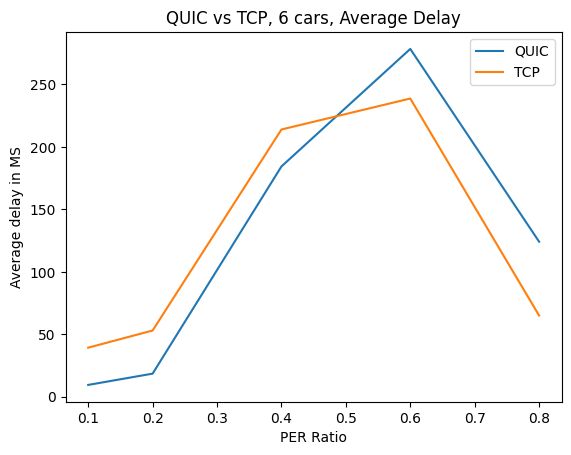

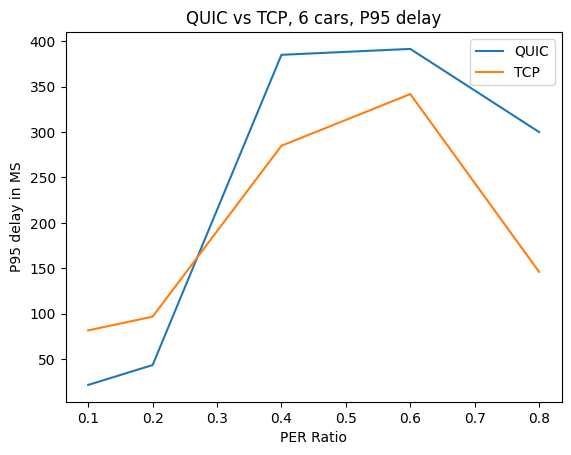

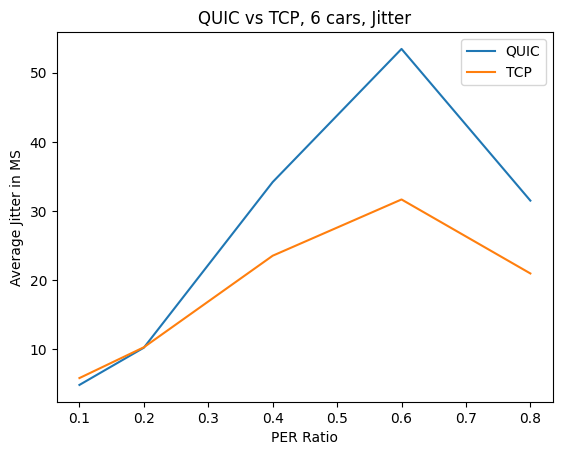

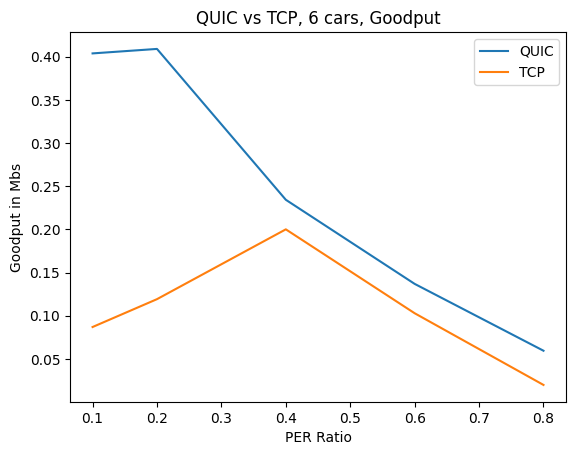

In [ ]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying PER, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying PER, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying PER, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying PER, Goodput","PER Ratio","Goodput in Mbs")

In [75]:
CombinedFileName="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,MedianTCPResults,delimiter=',')

Median results


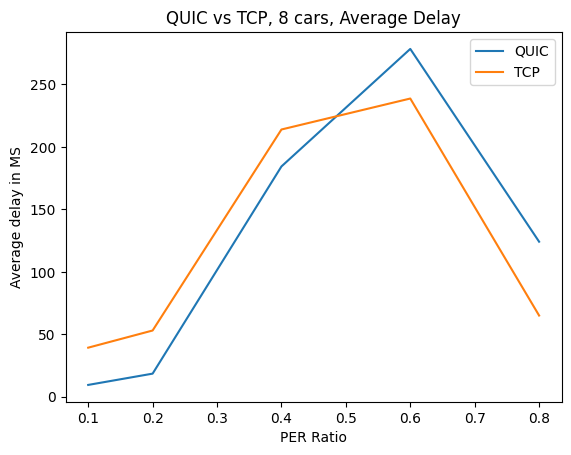

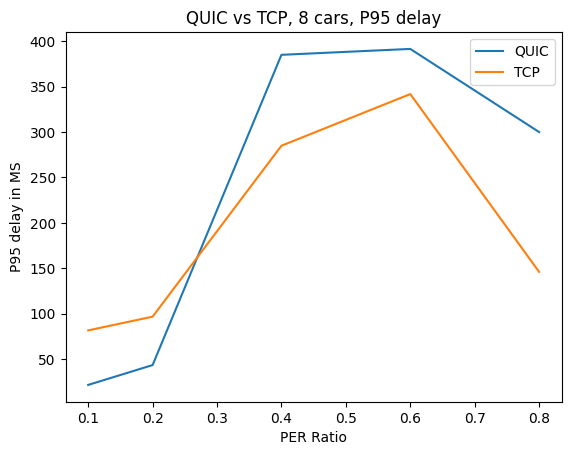

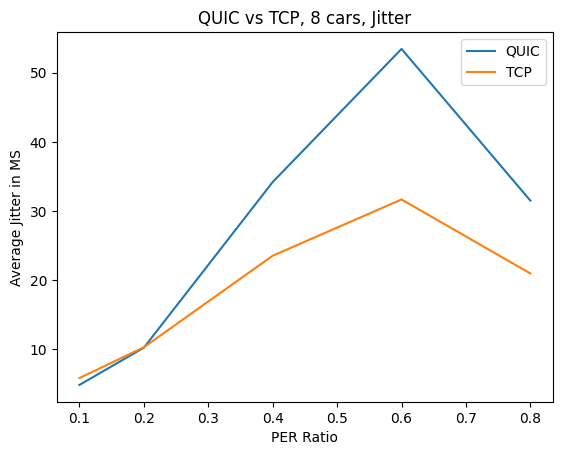

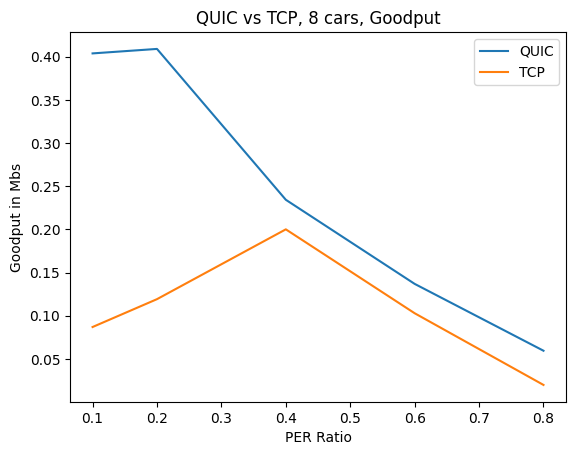

In [69]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","PER Ratio","Goodput in Mbs")


In [99]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfVehicles,Experiment1Folder+"/"+QUICDataFolder, Experiment1Folder+"/"+TCPDataFolder)

In [100]:
CombinedFileNameMedian="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,MedianTCPResults,delimiter=',')

CombinedFileNameAverage="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,AverageTCPResults,delimiter=',')


Average results


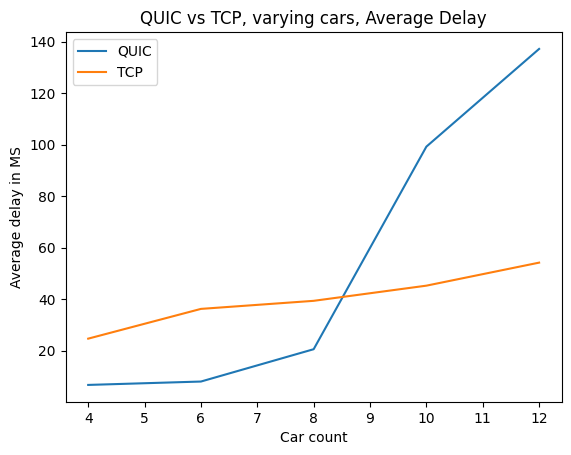

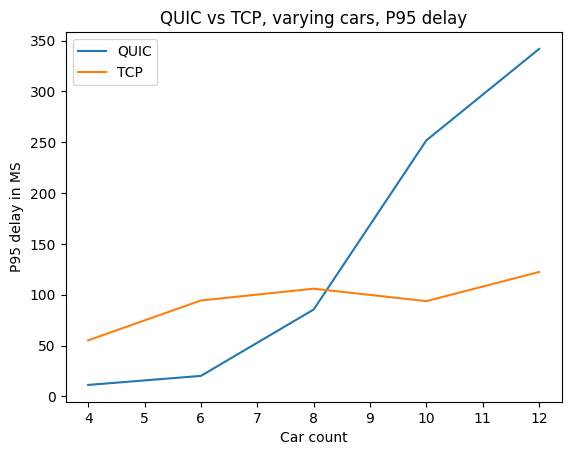

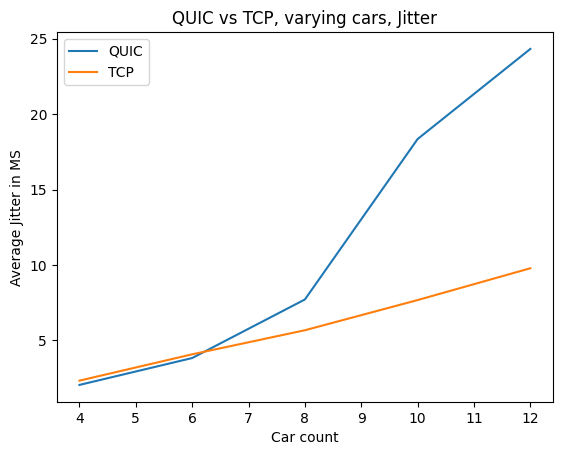

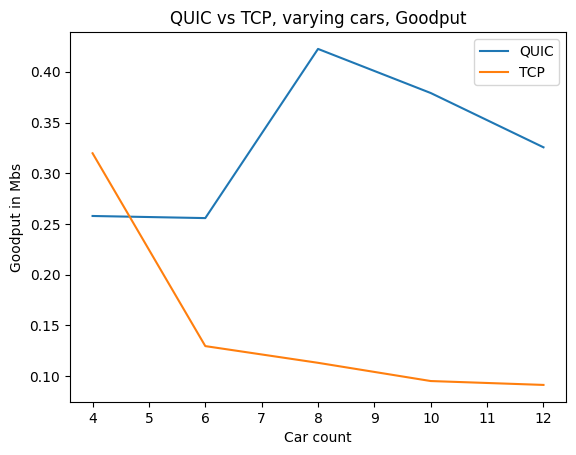

In [101]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying cars, Average Delay","Car count","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying cars, P95 delay","Car count","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying cars, Jitter","Car count","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying cars, Goodput","Car count","Goodput in Mbs")

Median results


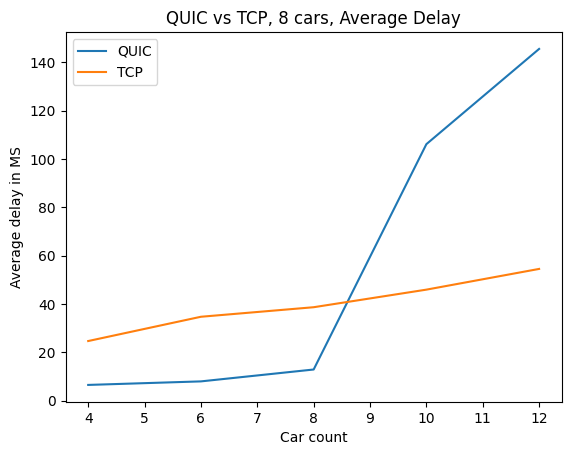

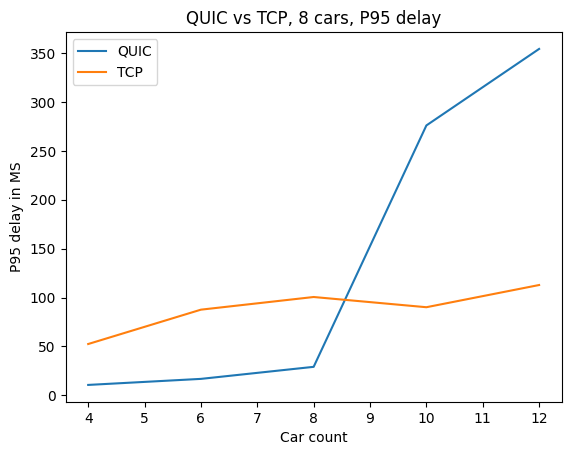

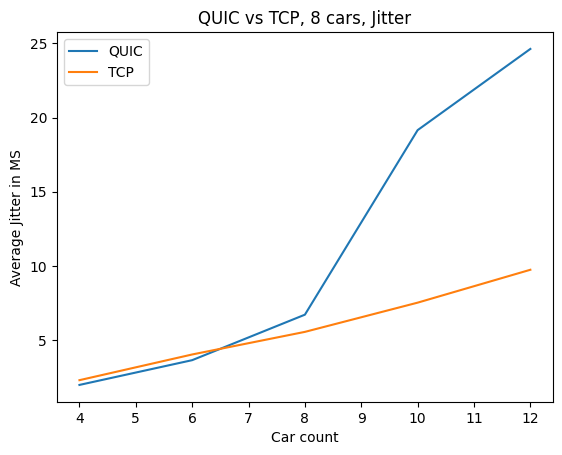

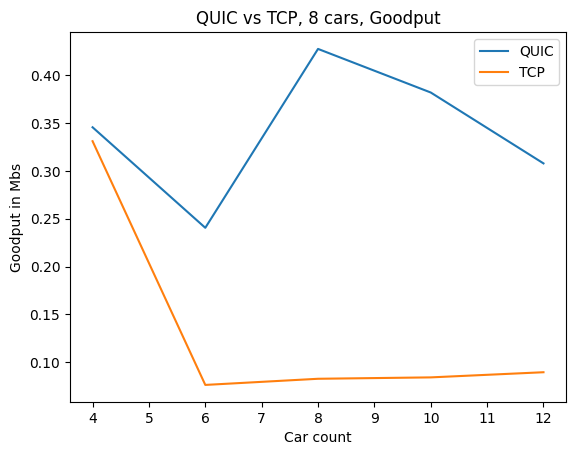

In [83]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","Car count","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","Car count","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","Car count","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(VEHICLEINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","Car count","Goodput in Mbs")


Experiment 2 Speed test

In [91]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfSpeedValues,Experiment2Folder+"/"+QUICDataFolder, Experiment2Folder+"/"+TCPDataFolder)
CombinedFileNameMedian="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,MedianTCPResults,delimiter=',')

CombinedFileNameAverage="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,AverageTCPResults,delimiter=',')

Average results


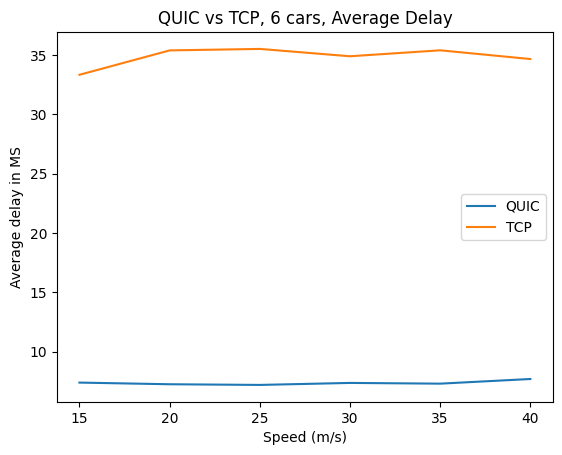

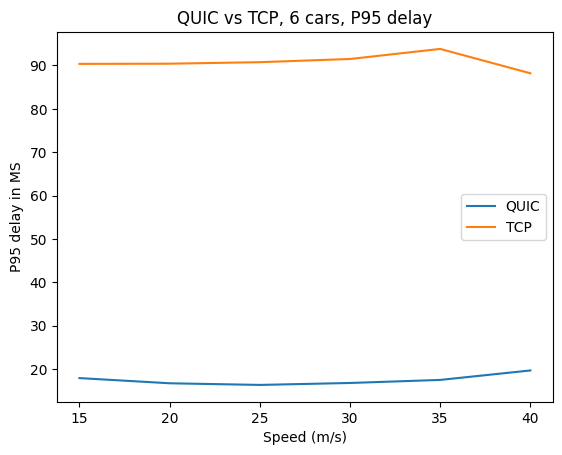

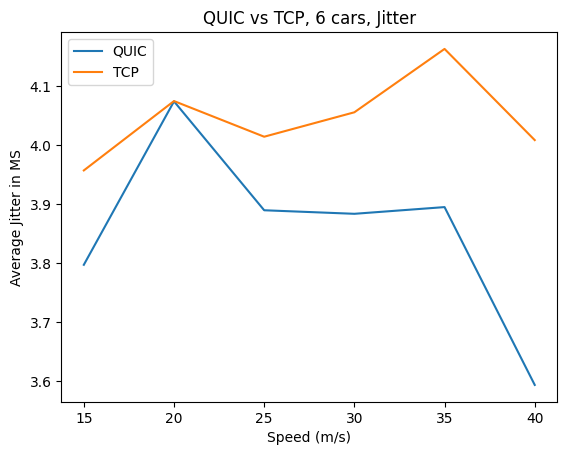

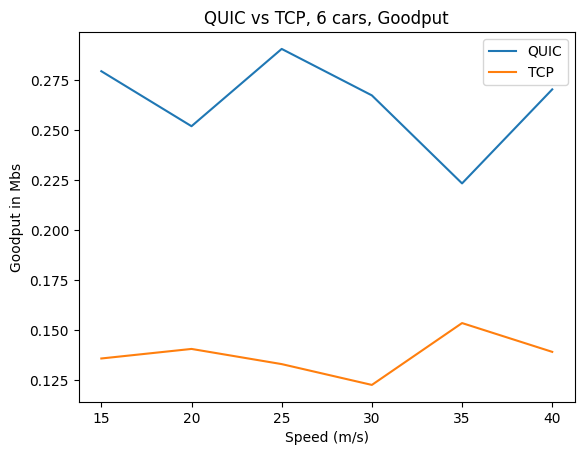

Median results


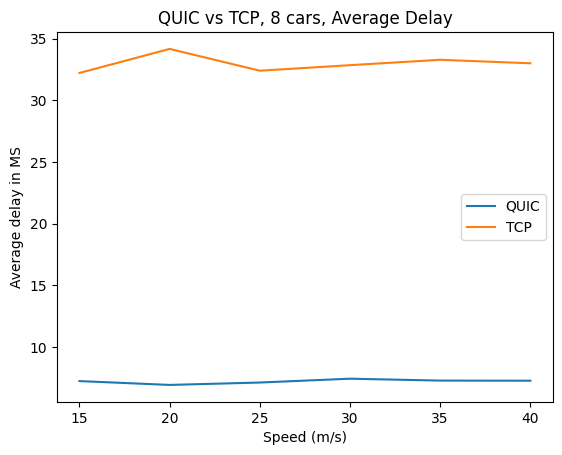

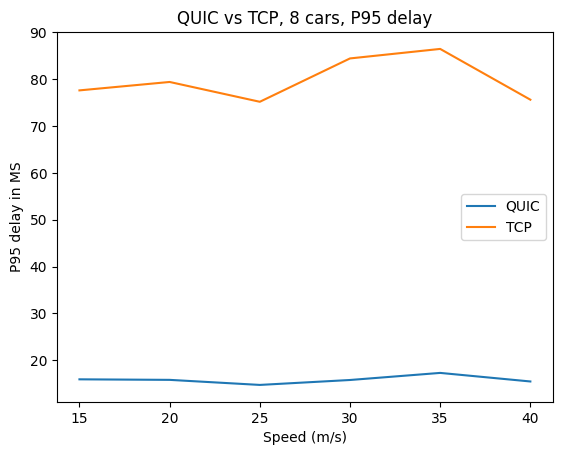

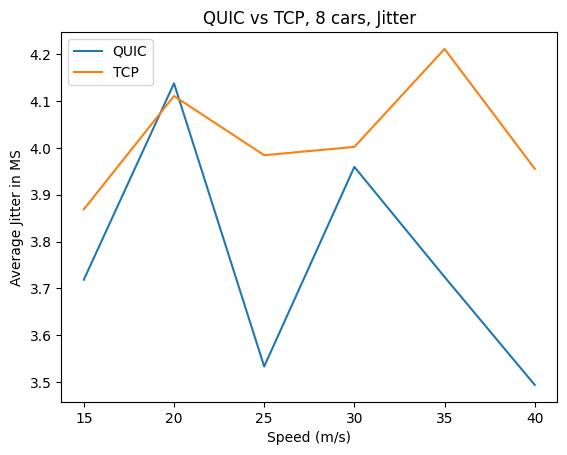

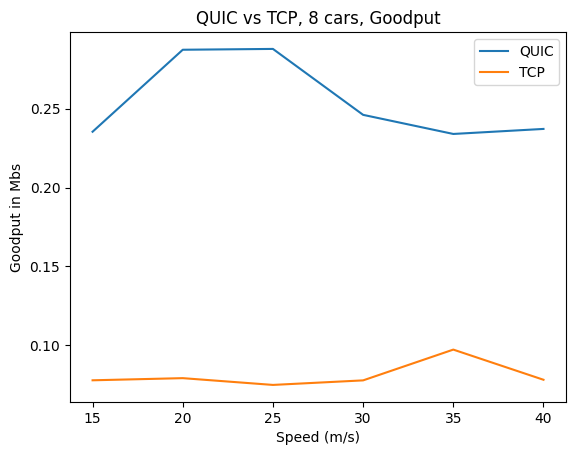

In [95]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 6 cars, Average Delay","Speed (m/s)","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 6 cars, P95 delay","Speed (m/s)","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 6 cars, Jitter","Speed (m/s)","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 6 cars, Goodput","Speed (m/s)","Goodput in Mbs")



print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","Speed (m/s)","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","Speed (m/s)","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","Speed (m/s)","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=1,usecols=(SPEEDINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","Speed (m/s)","Goodput in Mbs")
